# r-DEP

This notebook shows a minimal, reproducible example for some of the features of the r-DEP implementation.  
Two l-DEP estimators will be created, one for each available solver.
They will both be trained on a toy binary dataset (scikit-learn's "two moons" with noise) and their decision boundary will be displayed with matplotlib.

## 1. Train the r-DEP estimators

Let us start by importing the necessary modules:

In [8]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from sklearn_morpho.classifiers.rdep import RDEP

We then create a dataset, optionally generated with a set seed for reproducibility.

Here, the points' labels are transformed from $\{0, 1\}$ to $\{red, blue\}$ to show how the estimator supports it.  
This will also be useful later, when displaying the results, but it is obviously not mandatory.

In [9]:
random_state = np.random.RandomState(42)

X, y = make_moons(n_samples=1000, noise=0.2, random_state=random_state)
y = np.array(['red', 'blue'])[y]

A perceptron can then be created, then trained on this dataset.  
Here, the parameters are all left to the default values, except for:

- `random_state` for reproducibility once again
- `verbose` to display useful information

The other parameters are described in `help(RDEP)` and will not be covered here.

Finally, the dataset is split in two parts using `train_test_split`: one for training and another for testing, to avoid bias.

An important note is that the r-DEP will attempt to internally assign a positive label to the class whose centroid generally has higher coordinate values.  
In the case that the classes determination (using sklearn's `unique_labels`) makes for an inadequate ordering (`classes[1]` being in the lower half of the space), the r-DEP will accomodate by internally swapping its output to give the correct prediction.  
What this means is that the prediction should work no matter which class is the one with generally higher coordinates.

In [10]:
rdep = RDEP(verbose=1, random_state=random_state)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state
)

rdep.fit(X_train, y_train)

Starting fitting with DCCP (with manual linearization)
Epoch 1, training cost: 31.74479734, validation: 16.00831715
Epoch 2, training cost: 31.74479734, validation: 16.00831715
Epoch 3, training cost: 31.74479734, validation: 16.00831715
Epoch 4, training cost: 31.74479734, validation: 16.00831715
Epoch 5, training cost: 31.74479734, validation: 16.00831715
Epoch 6, training cost: 31.74479734, validation: 16.00831715
DCCP done in 6 epochs, final validation cost is 16.00831715 in 0.29s


,lambda_bounds,"(0.001, ...)"
,margin,0.0
,penalty,0.0
,validation_ratio,0.3
,weighting_method,None
,stopping_methods,None
,use_dccp_library,False
,verbose,1
,random_state,RandomState(M...0x7F4B08531040


Notice how two solving methods are available: the default one uses manual linearization of CCP constraints and multiple epochs, while the other uses the `'dccp'` solver from the `dccp` library.

Testing done by the developers of this library showed that the second solver was slower.
Furthermore, the manual linearization method allows for the use of custom stopping methods (like early stopping, maximum number of iterations...) and uses a validation set.
However, because of its genericity it may perform better than the manual linearization in specific applications, especially since there being no transformation applied to the data means the manual linearization may be too agressive.

To choose the solver, specify a boolean value to the `use_dccp_library` parameter when instantiating an estimator.

In [11]:
rdep_dccp = RDEP(use_dccp_library=True, verbose=1, random_state=random_state)
rdep_dccp.fit(X_train, y_train)

Starting fitting with DCCP (with dccp library)
DCCP done, final validation cost is 0.00000000 in 3.18s


The estimators are now trained, it is now possible to display the results of the training.

## 2. Display the results

Let us once again import useful modules to display the results and calculate the F1 score.

Scikit-learn implements the `DecisionBoundaryDisplay` function, which will be used here to display the decision boundary.

In [12]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import f1_score

We can now calculate the F1 score:

Since the labels are not numbered here (they are color names), a `pos_label` is explicitly defined.

In [13]:
score_test = f1_score(y_test, rdep.predict(X_test), pos_label=np.unique(y)[1])
score_test_dccp = f1_score(
    y_test, rdep_dccp.predict(X_test), pos_label=np.unique(y)[1]
)

Now for the results:

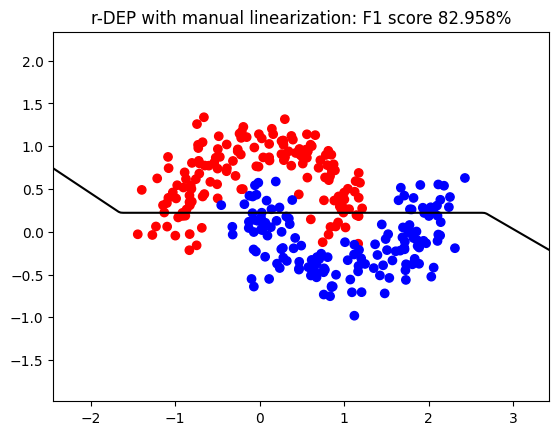

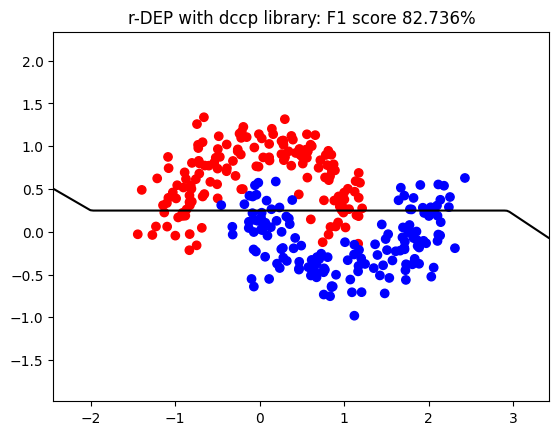

In [14]:
for name, estimator, score in (
    ('r-DEP with manual linearization', rdep, score_test),
    ('r-DEP with dccp library', rdep_dccp, score_test_dccp),
):
    # draw the decision boundary
    disp = DecisionBoundaryDisplay.from_estimator(
        estimator,
        X_test,
        response_method='decision_function',
        grid_resolution=200,
        plot_method='contour',
        levels=[0],
        colors='black',
    )

    # add the points
    ax = disp.ax_
    ax.scatter(*X_test.T, color=y_test)
    ax.title.set_text(f'{name}: F1 score {score * 100:.3f}%')
    plt.show()